# Artificial Neural Nets (ANN)

In [1]:
from tensorflow import keras # import deep learning libraries
from tensorflow.keras import layers

Loading data

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data() 

In [58]:
X_train.shape, X_test.shape # 28 * 28 pixel with 1 (greyscale)

((55000, 28, 28), (10000, 28, 28))

In [59]:
X_train[51]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         46, 105, 254, 254, 254, 254, 255, 239,  41,   0,   0,   0,   0,
          0,   0],
       [  

Display Number

In [60]:
import matplotlib.pyplot as plt

In [61]:
def number(index):
    plt.imshow(X_train[index])
    print("---" * 15)
    print(f"The number is {y_train[index]}")
    print("---" * 15)

---------------------------------------------
The number is 9
---------------------------------------------


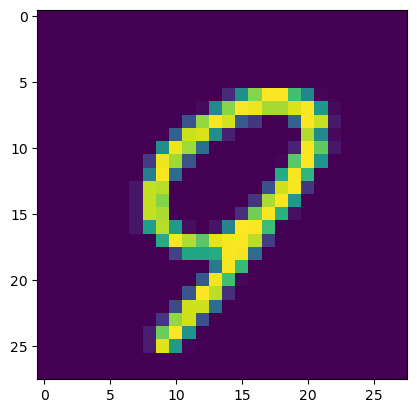

In [62]:
import random
index = random.randrange(0, 60000)
number(index)

Converting data

Flatten Image (28 * 28) pixels to 784 element array

In [8]:
X_train = X_train.reshape(len(X_train), 28 * 28)
X_test = X_test.reshape(len(X_test), 28 * 28)

In [9]:
X_train.shape, X_test.shape

((60000, 784), (10000, 784))

In [10]:
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

Feature Scaling

In [11]:
X_train = X_train / 255
X_test = X_test / 255

Neural Network 1

In [12]:
model = keras.Sequential([
    layers.Dense(10, activation="sigmoid", input_shape=(784, ))
])

In [13]:
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics="accuracy")

In [14]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 1s 666us/step - loss: 0.4680 - accuracy: 0.8778
Epoch 2/5
1875/1875 [==============================] - 1s 689us/step - loss: 0.3035 - accuracy: 0.9151
Epoch 3/5
1875/1875 [==============================] - 1s 676us/step - loss: 0.2831 - accuracy: 0.9204
Epoch 4/5
1875/1875 [==============================] - 1s 656us/step - loss: 0.2727 - accuracy: 0.9245
Epoch 5/5
1875/1875 [==============================] - 1s 679us/step - loss: 0.2668 - accuracy: 0.9253


Test Prediction

In [15]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 561us/step - loss: 0.2699 - accuracy: 0.9243


[0.2698836326599121, 0.9243000149726868]

In [16]:
predictions = model.predict(X_test)

313/313 [==============================] - 0s 487us/step


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [18]:
predictions = [value.argmax() for value in predictions]

<AxesSubplot:>

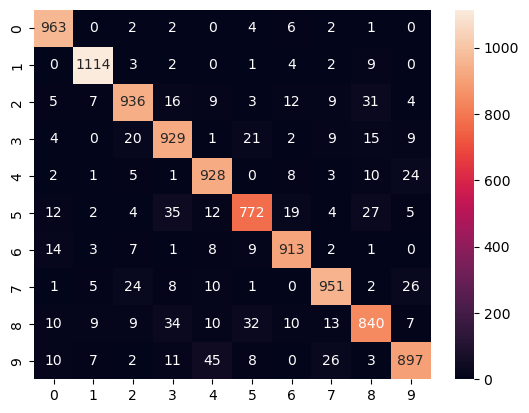

In [19]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d")

In [20]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.98      0.98      1135
           2       0.92      0.91      0.92      1032
           3       0.89      0.92      0.91      1010
           4       0.91      0.95      0.93       982
           5       0.91      0.87      0.89       892
           6       0.94      0.95      0.95       958
           7       0.93      0.93      0.93      1028
           8       0.89      0.86      0.88       974
           9       0.92      0.89      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Neural Network 2

In [21]:
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(784, )),
    layers.Dense(10, activation="softmax")
])

TensorBoard

In [22]:
tensorboard = keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

In [23]:
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics="accuracy")

In [24]:
model.fit(X_train, y_train, epochs=5, callbacks=[tensorboard])

Epoch 1/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3102 - accuracy: 0.9114
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.1450 - accuracy: 0.9578
Epoch 3/5
1875/1875 [==============================] - 2s 983us/step - loss: 0.1033 - accuracy: 0.9686
Epoch 4/5
1875/1875 [==============================] - 2s 838us/step - loss: 0.0808 - accuracy: 0.9759
Epoch 5/5
1875/1875 [==============================] - 2s 875us/step - loss: 0.0662 - accuracy: 0.9800


Test Prediction

In [25]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 684us/step - loss: 0.0930 - accuracy: 0.9715


[0.0930299386382103, 0.9714999794960022]

In [26]:
predictions = model.predict(X_test)

313/313 [==============================] - 0s 572us/step


In [27]:
predictions = [value.argmax() for value in predictions]

<AxesSubplot:>

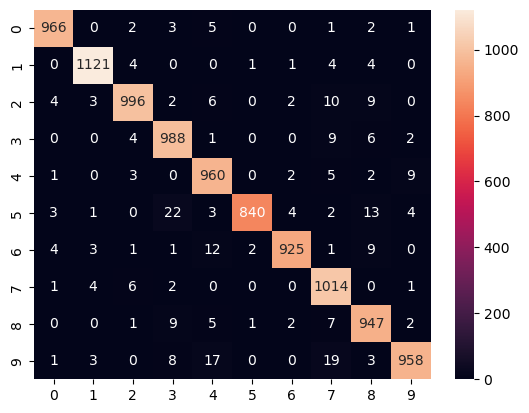

In [28]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d")

In [29]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.95      0.98      0.97      1010
           4       0.95      0.98      0.96       982
           5       1.00      0.94      0.97       892
           6       0.99      0.97      0.98       958
           7       0.95      0.99      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.98      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



CNN

In [46]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [47]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Data Split

In [48]:
# Reserve 10,000 samples for validation
# X_val = X_train[-5000:]
# y_val = y_train[-5000:]


X_train = X_train[:-5000]
y_train = y_train[:-5000]


In [49]:
model = keras.Sequential([
    
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPool2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPool2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

TensorBoard

In [50]:
tensorboard = keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

In [51]:
model.compile(
    optimizer="rmsprop", 
    # optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics="accuracy")

In [52]:
model.fit(X_train, y_train, epochs=10, callbacks=[tensorboard])
# model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
1719/1719 [==============================] - 21s 12ms/step - loss: 0.4514 - accuracy: 0.9413
Epoch 2/10
1719/1719 [==============================] - 20s 11ms/step - loss: 0.0725 - accuracy: 0.9810
Epoch 3/10
1719/1719 [==============================] - 22s 13ms/step - loss: 0.0568 - accuracy: 0.9854
Epoch 4/10
1719/1719 [==============================] - 24s 14ms/step - loss: 0.0502 - accuracy: 0.9879
Epoch 5/10
1719/1719 [==============================] - 24s 14ms/step - loss: 0.0482 - accuracy: 0.9887
Epoch 6/10
1719/1719 [==============================] - 25s 14ms/step - loss: 0.0475 - accuracy: 0.9895
Epoch 7/10
1719/1719 [==============================] - 26s 15ms/step - loss: 0.0465 - accuracy: 0.9897
Epoch 8/10
1719/1719 [==============================] - 22s 13ms/step - loss: 0.0495 - accuracy: 0.9904
Epoch 9/10
1719/1719 [==============================] - 26s 15ms/step - loss: 0.0457 - accuracy: 0.9903
Epoch 10/10
1719/1719 [==============================] - 28s 16m

Test Prediction

In [53]:
model.evaluate(X_test, y_test)
# model.evaluate(X_val, y_val)

313/313 [==============================] - 2s 6ms/step - loss: 0.1857 - accuracy: 0.9745


[0.18565472960472107, 0.9745000004768372]

In [54]:
predictions = model.predict(X_test)

313/313 [==============================] - 2s 6ms/step


In [55]:
predictions = [value.argmax() for value in predictions]

<AxesSubplot:>

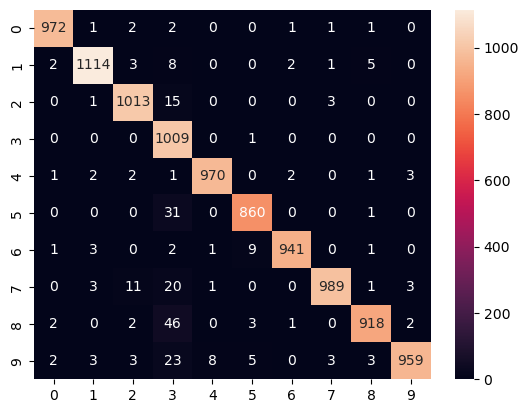

In [56]:
# sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d")
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d")

In [57]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.98      0.98      1135
           2       0.98      0.98      0.98      1032
           3       0.87      1.00      0.93      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.96      0.97       892
           6       0.99      0.98      0.99       958
           7       0.99      0.96      0.98      1028
           8       0.99      0.94      0.96       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.98      0.97      0.97     10000

